In [1]:
import pandas as pd
df = pd.read_csv('cybersecurity_intrusion_data.csv')
df.head()

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [2]:
df.browser_type.head()
df.session_duration.info()
df[[
    "network_packet_size",
    "session_duration",
    "login_attempts",
    "protocol_type",
    "browser_type"
]].describe(include="all")

<class 'pandas.core.series.Series'>
RangeIndex: 9537 entries, 0 to 9536
Series name: session_duration
Non-Null Count  Dtype  
--------------  -----  
9537 non-null   float64
dtypes: float64(1)
memory usage: 74.6 KB


,network_packet_size,session_duration,login_attempts,protocol_type,browser_type
count,9537.000000,9537.000000,9537.000000,9537,9537
unique,NaN,NaN,NaN,3,5
top,NaN,NaN,NaN,TCP,Chrome
freq,NaN,NaN,NaN,6624,5137
mean,500.430639,792.745312,4.032086,NaN,NaN
std,198.379364,786.560144,1.963012,NaN,NaN
min,64.000000,0.500000,1.000000,NaN,NaN
25%,365.000000,231.953006,3.000000,NaN,NaN
50%,499.000000,556.277457,4.000000,NaN,NaN
75%,635.000000,1105.380602,5.000000,NaN,NaN


In [3]:
df = df.drop(columns=["session_id"])

In [51]:
df.isnull().sum()

,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,1966
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


In [6]:
#ok so its all just that one
percentage_missing = df.isnull().sum().sum() / df['encryption_used'].value_counts().sum()
if percentage_missing > .1:
  print("use a constant fill value")
else:
  print("use the most common fill value")

use the most common fill value


In [7]:
from sklearn.impute import SimpleImputer
categorical_imputer = SimpleImputer(strategy="constant", fill_value="MISSING")
df[["encryption_used"]] = categorical_imputer.fit_transform(df[["encryption_used"]])
df.isnull().sum() #check this worked

,0
network_packet_size,0
protocol_type,0
login_attempts,0
session_duration,0
encryption_used,0
ip_reputation_score,0
failed_logins,0
browser_type,0
unusual_time_access,0
attack_detected,0


In [9]:
#this is where i really start to get shaky on what's going on
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline

# dropping text attributes
num_attribs = list(df.drop("protocol_type", axis=1).drop("encryption_used", axis=1).drop("browser_type", axis=1))

cat_attribs =list(["protocol_type", "encryption_used", "browser_type",])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler()),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", OneHotEncoder(), cat_attribs),
                                  ])
connections_prepared = full_pipeline.fit_transform(df)
print(connections_prepared)

[[ 0.49689911 -0.01634592 -0.38112504 ...  0.          0.
   0.        ]
 [-0.14332201 -0.52579383  0.97295964 ...  1.          0.
   0.        ]
 [ 0.64813245 -0.52579383 -0.91250324 ...  0.          0.
   0.        ]
 ...
 [ 0.82457134  0.49310198 -0.96320007 ...  1.          0.
   0.        ]
 [-0.47603535 -0.01634592 -0.89772872 ...  0.          0.
   0.        ]
 [-0.80874869  1.00254989 -0.89745912 ...  0.          0.
   0.        ]]


<Axes: >

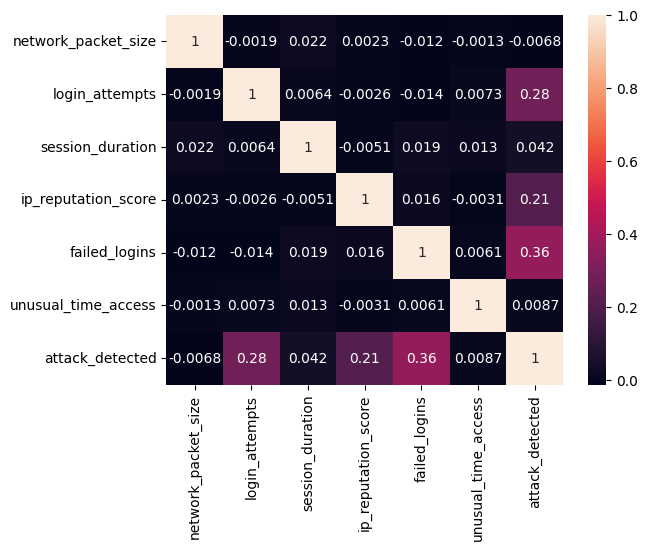

In [10]:
numerical_df = df[num_attribs]

import seaborn as sns
corr_matrix = numerical_df.corr(method="pearson")

sns.heatmap(corr_matrix, annot=True)

<Axes: xlabel='login_attempts'>

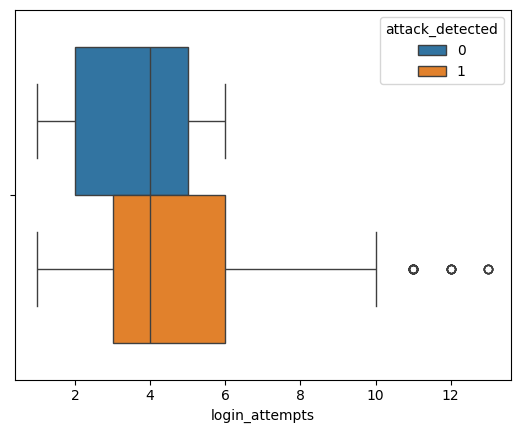

In [11]:
sns.boxplot(
    data=df,
    x="login_attempts",
    hue="attack_detected"
)

<Axes: xlabel='failed_logins'>

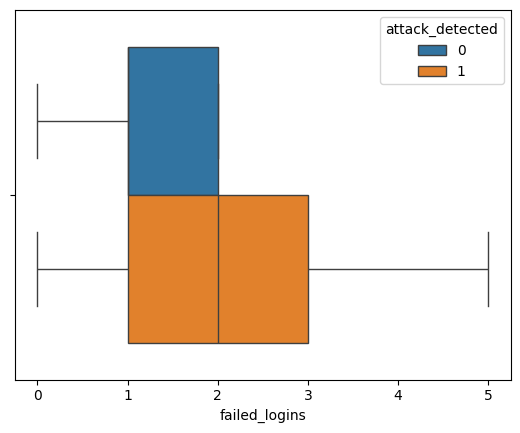

In [12]:
sns.boxplot(
    data=df,
    x="failed_logins",
    hue="attack_detected"
)

<Axes: xlabel='login_attempts', ylabel='failed_logins'>

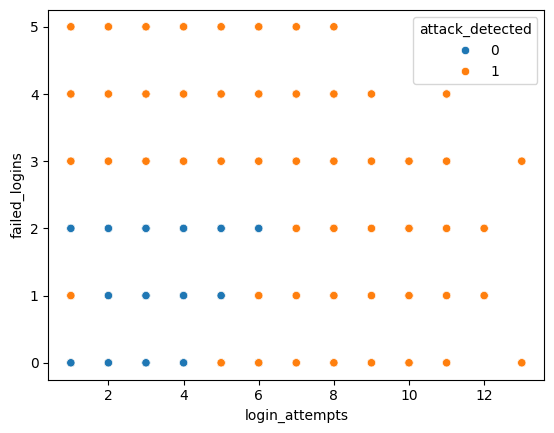

In [16]:
sns.scatterplot(
    data=df,
    x="login_attempts",
    y="failed_logins",
    hue="attack_detected",
)